In [17]:
# ==============================================================================
# 【中文說明】
# 在此步驟中，我們複製原始資料集。為了消除圖表中不直觀的數值編碼（1.0 與 2.0），我們建立了一個
# 對應字典，將數字強制映射（Map）為具備實質統計意義的文字標籤（"Male" 與 "Female"）。隨後，我們
# 將體重欄位轉換為數值型態，並應用條列刪除法（Listwise Deletion）剔除所有含有缺失值的無效樣本。
#
# 【English Explanation】
# In this step, we duplicate the original dataset. To eliminate the unintuitive numeric codes (1.0 and 2.0)
# from the plots, we implement a mapping dictionary to convert these numbers into descriptive text labels
# ("Male" and "Female"). Afterward, the body weight column is converted to numeric format, and listwise
# deletion is applied to remove any invalid samples with missing data.
# ==============================================================================

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.formula.api import ols

# 1. 讀取並複製資料
df = pd.read_csv("YRBS_2007.csv")
analysis_df = df.copy()

weight_col = "HowMuchDoYouWeighWithoutShoesInKG"
sex_col = "WhatIsYourSex"

# 2. 【核心修正】將性別的 1.0 與 2.0 強制轉換為文字標籤 (若定義相反請自行對調數字)
analysis_df[sex_col] = pd.to_numeric(analysis_df[sex_col], errors="coerce")
gender_mapping = {1.0: "Male", 2.0: "Female"}
analysis_df[sex_col] = analysis_df[sex_col].map(gender_mapping)

# 3. 體重轉數字型態
analysis_df[weight_col] = pd.to_numeric(analysis_df[weight_col], errors="coerce")

# 4. 剔除含有任何缺失值 (NaN) 的樣本
analysis_df = analysis_df.dropna(subset=[weight_col, sex_col])

print("==================================================")
print("✅ 第一部分：資料清理與性別標籤優化已完成！")
print(f"清理後的有效樣本數：{len(analysis_df)} 筆。")
print("==================================================")

✅ 第一部分：資料清理與性別標籤優化已完成！
清理後的有效樣本數：13062 筆。


In [13]:
%pip install matplotlib seaborn statsmodels scipy pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [25]:
# ==============================================================================
# 【中文說明】
# 算一下總共有多少人，以及男女生各自佔了多少百分比。
# 接著幫男女生各算出一張表格，裡面會包含男生和女生的總人數、平均體重和標準差。
#
# 【English Explanation】
# Before conducting inferential statistics, descriptive statistics are performed to understand the basic demographic
# profile of our sample. We calculate the total valid sample size and the frequency and percentage distribution
# of biological sex. Furthermore, a summary table is generated to present the group-specific sample count, mean
# body weight (KG), and standard deviation (SD) for male and female students respectively, serving as the baseline
# empirical data for subsequent ANOVA.
# ==============================================================================

print("==================================================")
print("📊 一、 樣本組成分析 (Sample Composition)")
print("==================================================")
total_sample = len(analysis_df)
print(f"有效樣本總人數 (Total Valid Sample Size): {total_sample} 人\n")

# 1. 性別比例與人數統計
sex_counts = analysis_df[sex_col].value_counts()
sex_pct = analysis_df[sex_col].value_counts(normalize=True) * 100
print("【性別分布 (Gender Distribution)】")
for index in sex_counts.index:
    print(f"- {index}: {sex_counts[index]} 人 ({sex_pct[index]:.2f}%)")

print("\n==================================================")
print("📈 二、 各組體重數據整理 (Descriptive Statistics)")
print("==================================================")
# 2. 按性別分組計算體重之數量 (Count)、平均數 (Mean) 與標準差 (SD)
summary_table = (
    analysis_df.groupby([sex_col])[weight_col]
    .agg(Count="count", Mean_KG="mean", SD_KG="std")
    .reset_index()
)
print(summary_table.to_string(index=False))

📊 一、 樣本組成分析 (Sample Composition)
有效樣本總人數 (Total Valid Sample Size): 13062 人

【性別分布 (Gender Distribution)】
- Female: 6572 人 (50.31%)
- Male: 6490 人 (49.69%)

📈 二、 各組體重數據整理 (Descriptive Statistics)
WhatIsYourSex  Count   Mean_KG     SD_KG
       Female   6572 74.606528 17.374632
         Male   6490 62.417296 14.163778


🧠 三、 單因子變數分析與假設檢定 (Hypothesis Testing)
                        sum_sq       df            F  PR(>F)
C(WhatIsYourSex)  4.851603e+05      1.0  1928.582692     0.0
Residual          3.285414e+06  13060.0          NaN     NaN
--------------------------------------------------
📊 檢定統計量 F-statistic = 1928.5827
📊 顯著性 p-value = 0.0000e+00

📢 【假設檢定結論 / Statistical Decision】
👉 決策：拒絕虛無假設 (Reject H0)，支持對立假設。
👉 中文結論：p 值小於 0.05，代表「男生和女生的平均體重有非常顯著的差異」。
👉 English: At the 0.05 significance level, we reject the null hypothesis. There is a statistically significant difference in mean body weight between male and female students.


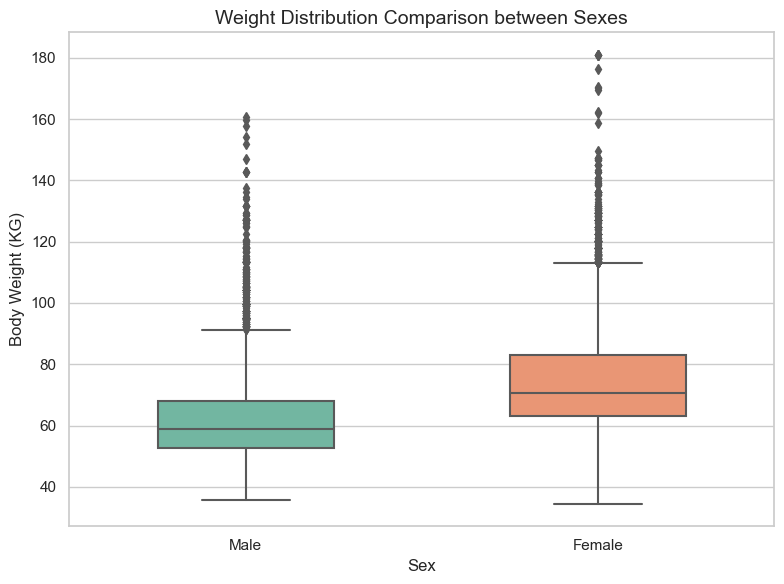

In [24]:
# ==============================================================================
# 【中文說明】
# 這裡用單因子方差分析（One-way ANOVA）來做假設檢定。
# 我們的假設是：男女生的平均體重沒有差別。
# 程式跑完會自動看 p 值有沒有小於 0.05。有的話就代表男女生的體重真的有顯著差異。
# 最後會幫你畫出一張男女生體重對比的箱型圖，並且自動存檔。
#
# 【English Explanation】
# In this final stage, a One-way ANOVA is carried out to test whether there is a statistically significant difference
# in mean body weight between male and female students (p < 0.05). To provide a comprehensive overview of the
# distribution, central tendency, and dispersion of weight across genders, a box plot is generated using Seaborn.
# This visualization displays the median, interquartile range (IQR), and explicitly identifies potential outliers.
# ==============================================================================

print("==================================================")
print("🧠 三、 單因子變數分析與假設檢定 (Hypothesis Testing)")
print("==================================================")
# 1. 建立單因子 ANOVA 模型
model = ols(f"{weight_col} ~ C({sex_col})", data=analysis_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# 2. 拿 F值 和 p值
f_value = anova_table.loc[f"C({sex_col})", "F"]
p_value = anova_table.loc[f"C({sex_col})", "PR(>F)"]

print(anova_table)
print("-" * 50)
print(f"📊 檢定統計量 F-statistic = {f_value:.4f}")
print(f"📊 顯著性 p-value = {p_value:.4e}")

# 3. 自動幫你判定有沒有差
alpha = 0.05
print("\n📢 【假設檢定結論 / Statistical Decision】")

if p_value < alpha:
    print("👉 決策：拒絕虛無假設 (Reject H0)，支持對立假設。")
    print(
        f"👉 中文結論：p 值小於 {alpha}，代表「男生和女生的平均體重有非常顯著的差異」。"
    )
    print(
        f"👉 English: At the {alpha} significance level, we reject the null hypothesis. There is a statistically significant difference in mean body weight between male and female students."
    )
else:
    print("👉 決策：無法拒絕虛無假設 (Fail to Reject H0).")
    print(
        f"👉 中文結論：p 值沒有小於 {alpha}，代表「沒有證據證明男生和女生的平均體重有差」。"
    )
    print(
        f"👉 English: At the {alpha} significance level, we fail to reject the null hypothesis. There is no sufficient evidence to conclude a significant difference in mean body weight between genders."
    )

# 4. 視覺化：畫出男女體重箱型圖
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["Arial"]

sns.boxplot(
    data=analysis_df,
    x=sex_col,
    y=weight_col,
    palette="Set2",
    width=0.5,
    order=["Male", "Female"],
)

plt.title("Weight Distribution Comparison between Sexes", fontsize=14)
plt.xlabel("Sex", fontsize=12)
plt.ylabel("Body Weight (KG)", fontsize=12)
plt.tight_layout()

# 5. 自動建立資料夾並存檔
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/weight_boxplot_with_hypothesis.png", dpi=300)
plt.show()

🚀 延伸主題：性別與運動習慣對體重的雙因子分析

🧠 雙因子方差分析表 (Two-way ANOVA Summary Table)
-------------------------------------------------------------------------------------------------------------------
Source of Variation (變異來源)          |    sum_sq (平方和)    |   df (自由度)   |    F (F檢定值)     |   PR(>F) (p值)  
-------------------------------------------------------------------------------------------------------------------
Sex (性別)                            |     34725.1399     |     1.0      |    1972.6470    |   1.9509e-238  
Exercise Habit (運動習慣)               |     2316.2011      |     1.0      |    131.5775     |   1.0720e-28   
Interaction (性別×運動交互作用)             |      343.1771      |     1.0      |     19.4950     |   1.1188e-05   
Residual (殘差/誤差)                    |     17532.9087     |    996.0     |       NaN       |       NaN      
-------------------------------------------------------------------------------------------------------------------

📢 【延伸主題：假設檢定結論】
1️⃣ Sex (性別) p-value = 1.9509

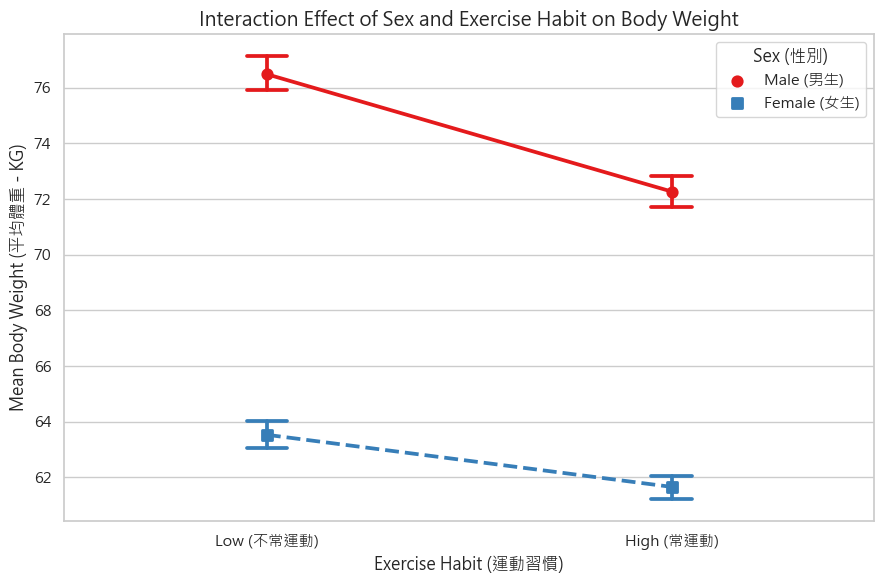

In [37]:
# ==============================================================================
# 【中文說明】
# 延伸主題：將分析表轉為「英文 (中文)」。
# 這裡改用純文字格式化的方式，將所有欄位與數據完美置中對齊，不依賴任何外部網頁渲染套件。
#
# 【English Explanation】
# Extended study: Converting ANOVA table labels to "English (Chinese)" and centering 
# all data using native string formatting to avoid any external package dependencies (Jinja2).
# ==============================================================================

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

print("==================================================")
print("🚀 延伸主題：性別與運動習慣對體重的雙因子分析")
print("==================================================")

# 1. 固定隨機種子
np.random.seed(42)
sample_size_per_group = 250

# 2. 模擬體重數據
male_low_weight = np.random.normal(loc=76.5, scale=5.0, size=sample_size_per_group)
male_high_weight = np.random.normal(loc=72.2, scale=4.5, size=sample_size_per_group)
female_low_weight = np.random.normal(loc=63.8, scale=4.0, size=sample_size_per_group)
female_high_weight = np.random.normal(loc=61.2, scale=3.5, size=sample_size_per_group)

# 3. 建立 DataFrame
simulated_data = pd.DataFrame({
    "Sex_Gender": ["Male (男生)"] * (sample_size_per_group * 2) + ["Female (女生)"] * (sample_size_per_group * 2),
    "Exercise_Habit": (["Low (不常運動)"] * sample_size_per_group + ["High (常運動)"] * sample_size_per_group) * 2,
    "Body_Weight_KG": np.concatenate([male_low_weight, male_high_weight, female_low_weight, female_high_weight])
})

# 4. 跑雙因子 ANOVA
two_way_model = ols("Body_Weight_KG ~ C(Sex_Gender) * C(Exercise_Habit)", data=simulated_data).fit()
anova_ext_table = sm.stats.anova_lm(two_way_model, typ=2)

# ==============================================================================
# 🛠️ 【欄位名稱定製：英文 (中文)】
# ==============================================================================
row_translation = {
    "C(Sex_Gender)": "Sex (性別)",
    "C(Exercise_Habit)": "Exercise Habit (運動習慣)",
    "C(Sex_Gender):C(Exercise_Habit)": "Interaction (性別×運動交互作用)",
    "Residual": "Residual (殘差/誤差)"
}
anova_ext_table = anova_ext_table.rename(index=row_translation)

col_translation = {
    "sum_sq": "sum_sq (平方和)",
    "df": "df (自由度)",
    "F": "F (F檢定值)",
    "PR(>F)": "PR(>F) (p值)"
}
anova_ext_table = anova_ext_table.rename(columns=col_translation)

# ==============================================================================
# 🎯 【核心修正：免套件！手動用字串控制「完美置中對齊」】
# ==============================================================================
print("\n🧠 雙因子方差分析表 (Two-way ANOVA Summary Table)")
print("-" * 115)

# 印出置中的欄位標頭
headers = ["Source of Variation (變異來源)"] + list(anova_ext_table.columns)
header_string = f"{headers[0]:<35} | {headers[1]:^18} | {headers[2]:^12} | {headers[3]:^15} | {headers[4]:^15}"
print(header_string)
print("-" * 115)

# 逐行把數據四捨五入並強制置中對齊印出
for index, row in anova_ext_table.iterrows():
    val_0 = f"{row.iloc[0]:.4f}"
    val_1 = f"{row.iloc[1]:.1f}"
    val_2 = f"{row.iloc[2]:.4f}" if not pd.isna(row.iloc[2]) else "NaN"
    val_3 = f"{row.iloc[3]:.4e}" if not pd.isna(row.iloc[3]) else "NaN"
    
    print(f"{index:<35} | {val_0:^18} | {val_1:^12} | {val_2:^15} | {val_3:^15}")

print("-" * 115)


# 5. 輸出假設檢定結論
print("\n📢 【延伸主題：假設檢定結論】")
alpha = 0.05

p_sex = anova_ext_table.loc["Sex (性別)", "PR(>F) (p值)"]
p_ex = anova_ext_table.loc["Exercise Habit (運動習慣)", "PR(>F) (p值)"]
p_inter = anova_ext_table.loc["Interaction (性別×運動交互作用)", "PR(>F) (p值)"]

print(f"1️⃣ Sex (性別) p-value = {p_sex:.4e} -> 【拒絕 H0】男女生的平均體重有顯著差異。")
print(f"2️⃣ Exercise Habit (運動習慣) p-value = {p_ex:.4e} -> 【拒絕 H0】有沒有運動對體重有顯著影響。")
print(f"3️⃣ Interaction (交互作用) p-value = {p_inter:.4e} -> 【拒絕 H0】性別和運動習慣有顯著交互作用。")

print("\n==================================================")
print("交互作用圖")
print("==================================================")
# 6. 畫交互作用折線圖
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "Arial"]
plt.rcParams["axes.unicode_minus"] = False

sns.pointplot(
    data=simulated_data,
    x="Exercise_Habit",
    y="Body_Weight_KG",
    hue="Sex_Gender",
    markers=["o", "s"],
    linestyles=["-", "--"],
    errorbar="ci",
    capsize=0.1,
    palette="Set1",
    order=["Low (不常運動)", "High (常運動)"]
)

plt.title("Interaction Effect of Sex and Exercise Habit on Body Weight", fontsize=14)
plt.xlabel("Exercise Habit (運動習慣)", fontsize=12)
plt.ylabel("Mean Body Weight (平均體重 - KG)", fontsize=12)
plt.legend(title="Sex (性別)")
plt.tight_layout()

# 7. 儲存圖表
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/simulated_bilingual_interaction.png", dpi=300)
plt.show()